*Conectar o Google Drive ao Google Colab, necessário para acessar os arquivos utilizados no projeto*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*Instalação das dependências*  
   Instalação da biblioteca YOLOv5 (Ultralytics), importação de bibliotecas e configurações iniciais.[texto do link](https://)

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17410, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 17410 (delta 63), reused 22 (delta 22), pack-reused 17326 (from 3)
Receiving objects: 100% (17410/17410), 16.30 MiB | 19.43 MiB/s, done.
Resolving deltas: 100% (11934/11934), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s e

**Treinamento do Modelo**  
   - Execução do treinamento por 30 e 60 épocas;
   - Salvamento automático dos melhores pesos.

In [ ]:
!python train.py --img 640 --batch 16 --epochs 30 --data /content/drive/MyDrive/FIAP/dataset/dataset.yaml --weights yolov5s.pt --name projeto_objetos_30epocas

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-04-29 19:55:05.506573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745956505.754164    2047 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745956505.825740    2047 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [ ]:
!python train.py --img 640 --batch 16 --epochs 60 --data /content/drive/MyDrive/FIAP/dataset/dataset.yaml --weights yolov5s.pt --name projeto_objetos_60epocas

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-04-29 20:19:44.708928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745957984.759194    8071 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745957984.774864    8071 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: W&B disabled due to login timeout.
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/FIAP/dataset/data

Resultados do Teste com 30 épocas.

Épocas são ciclos completos em que o modelo passa por todo o conjunto de dados de treinamento, ajustando seus parâmetros para aprender padrões e minimizar erros.


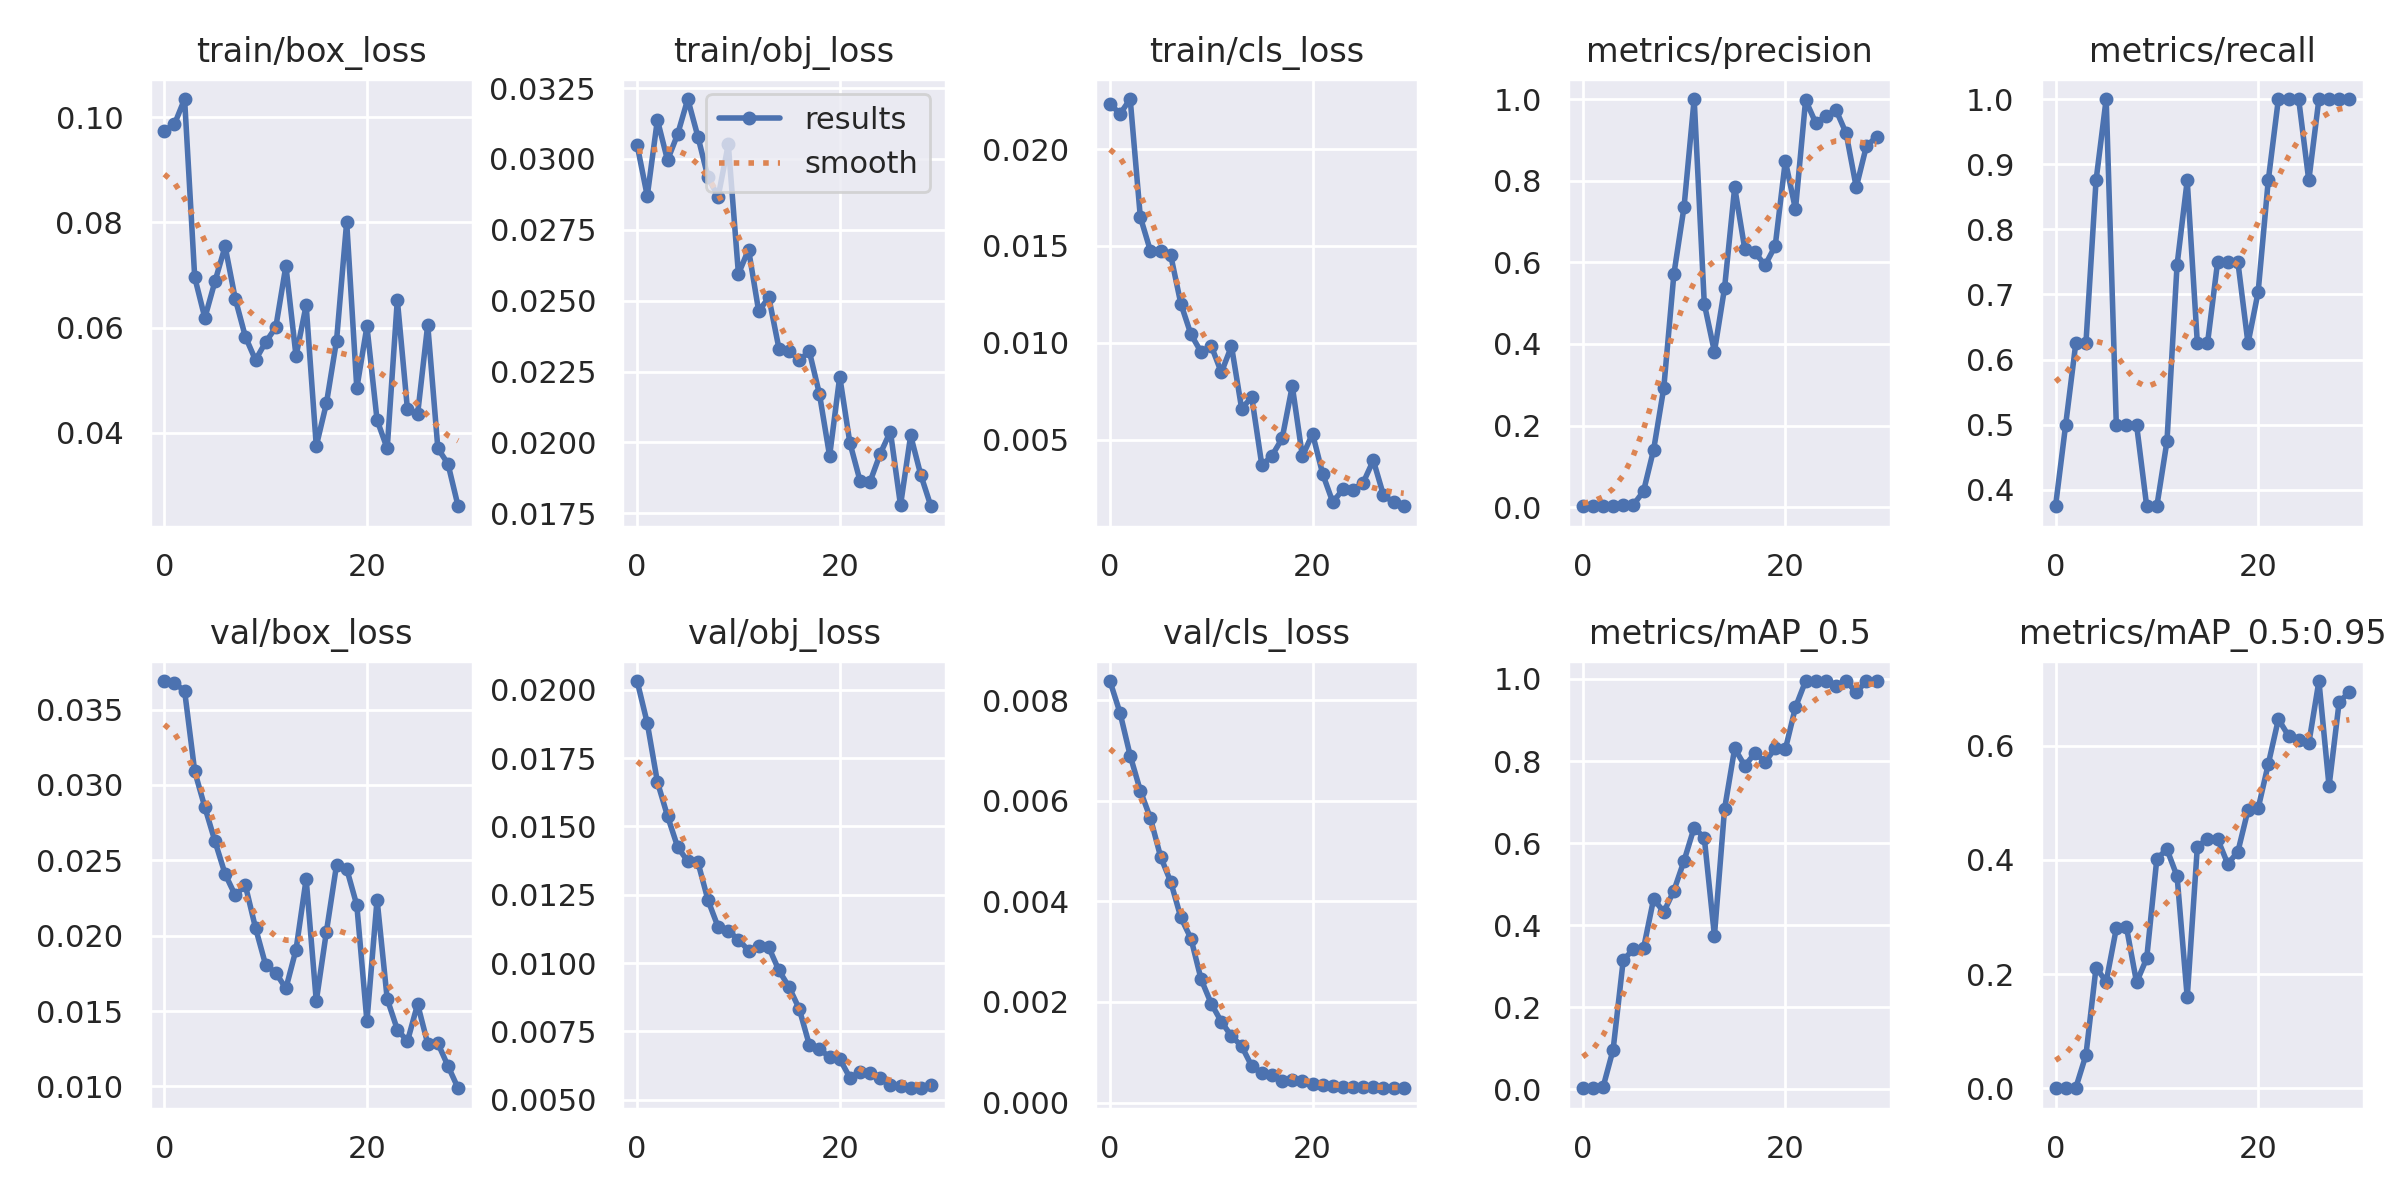

Resultado do Teste com 60 épocas.

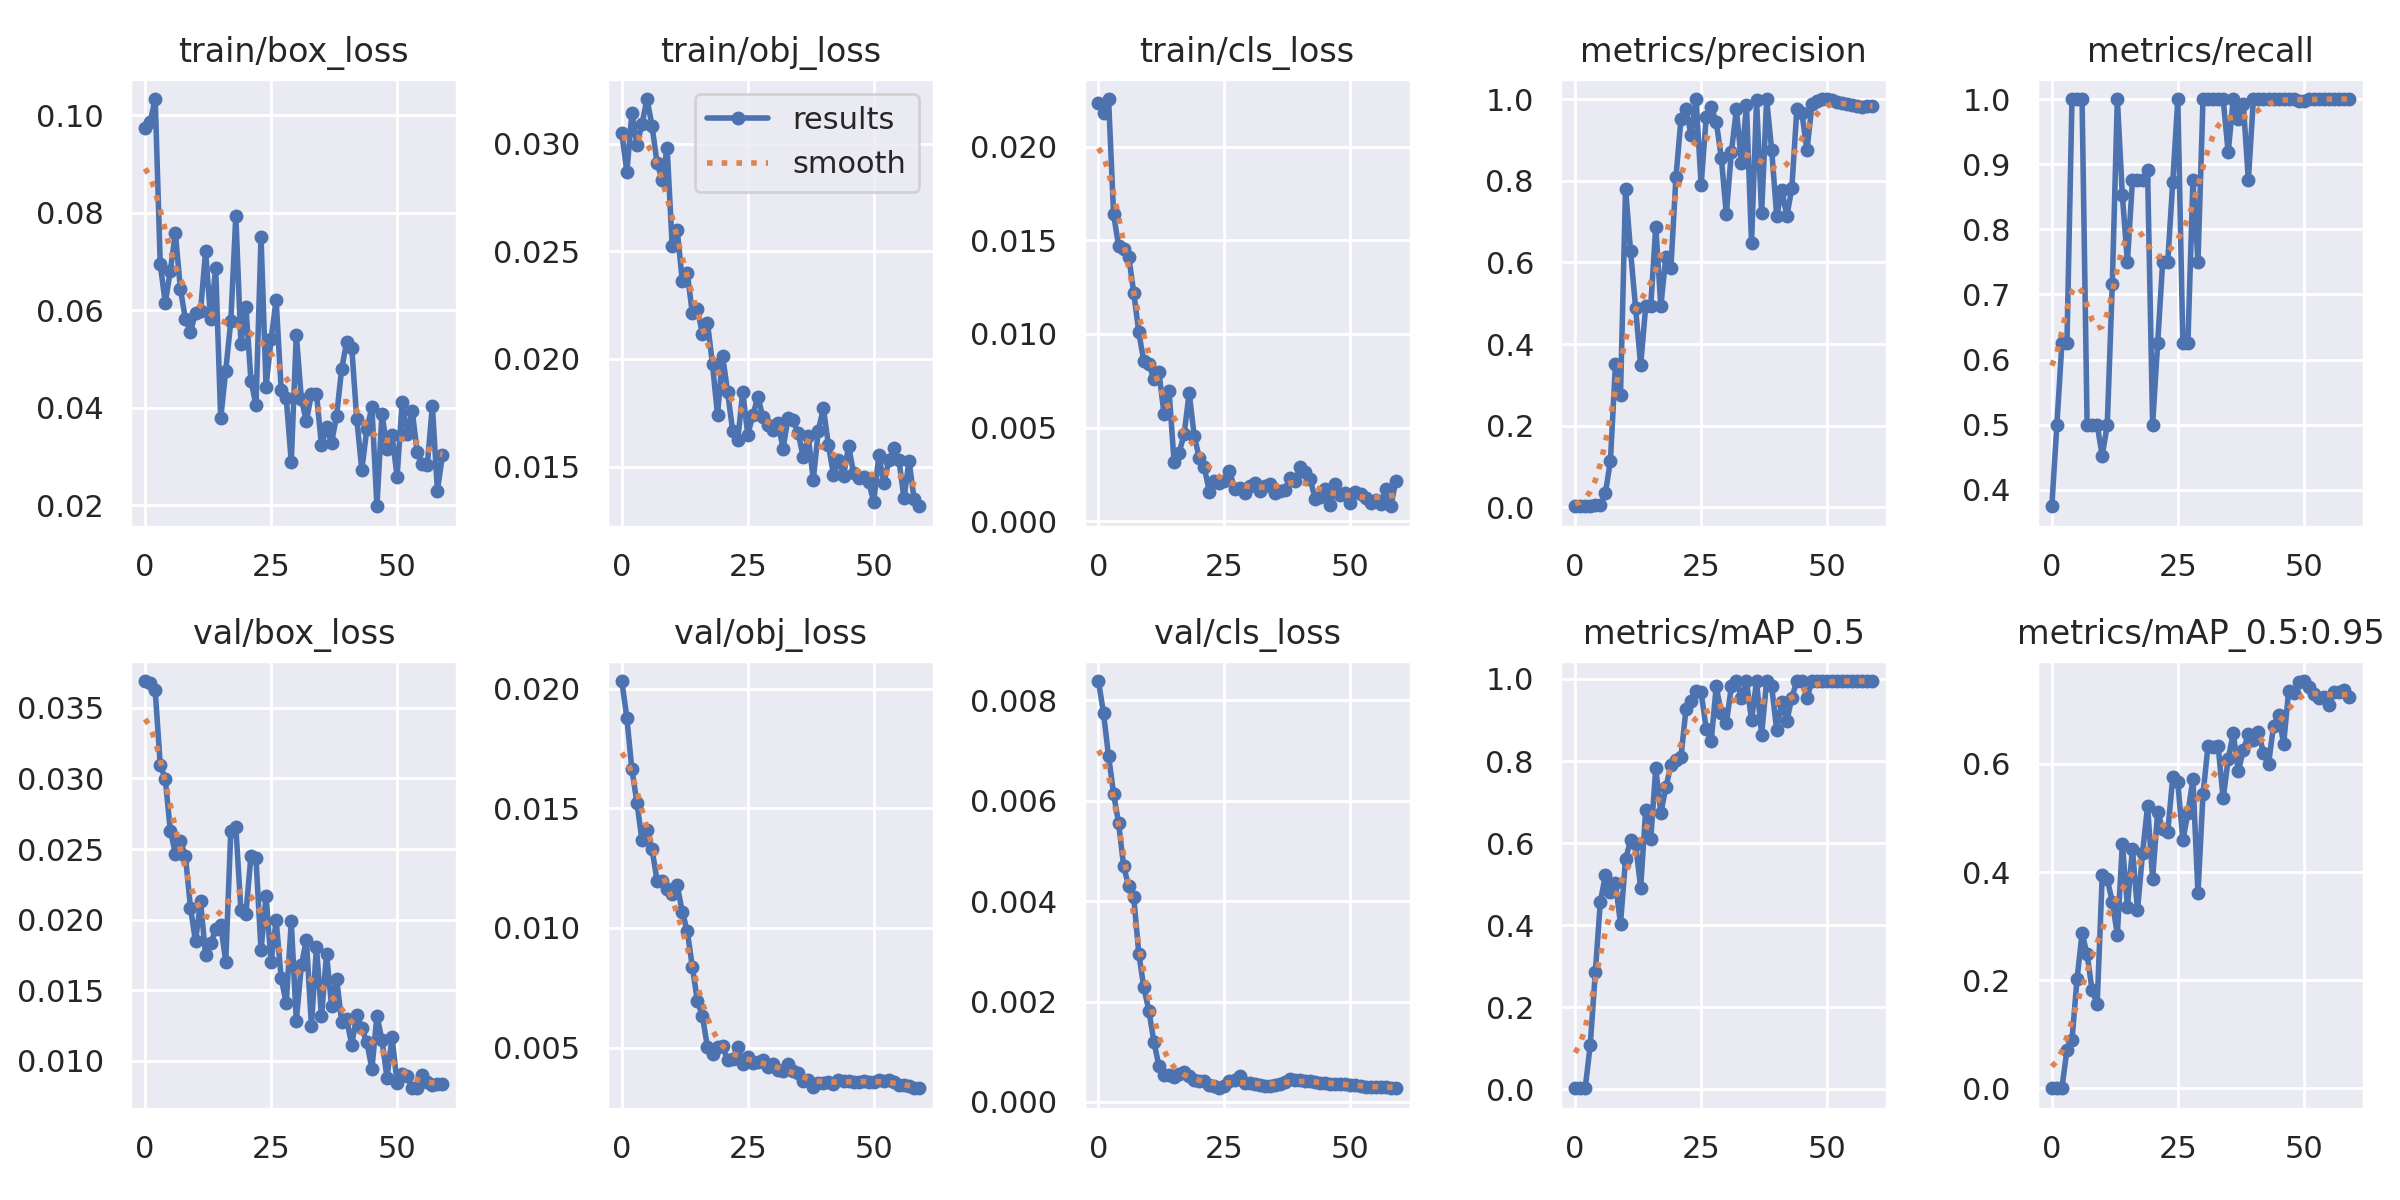

Imagens utilizadas para os testes.




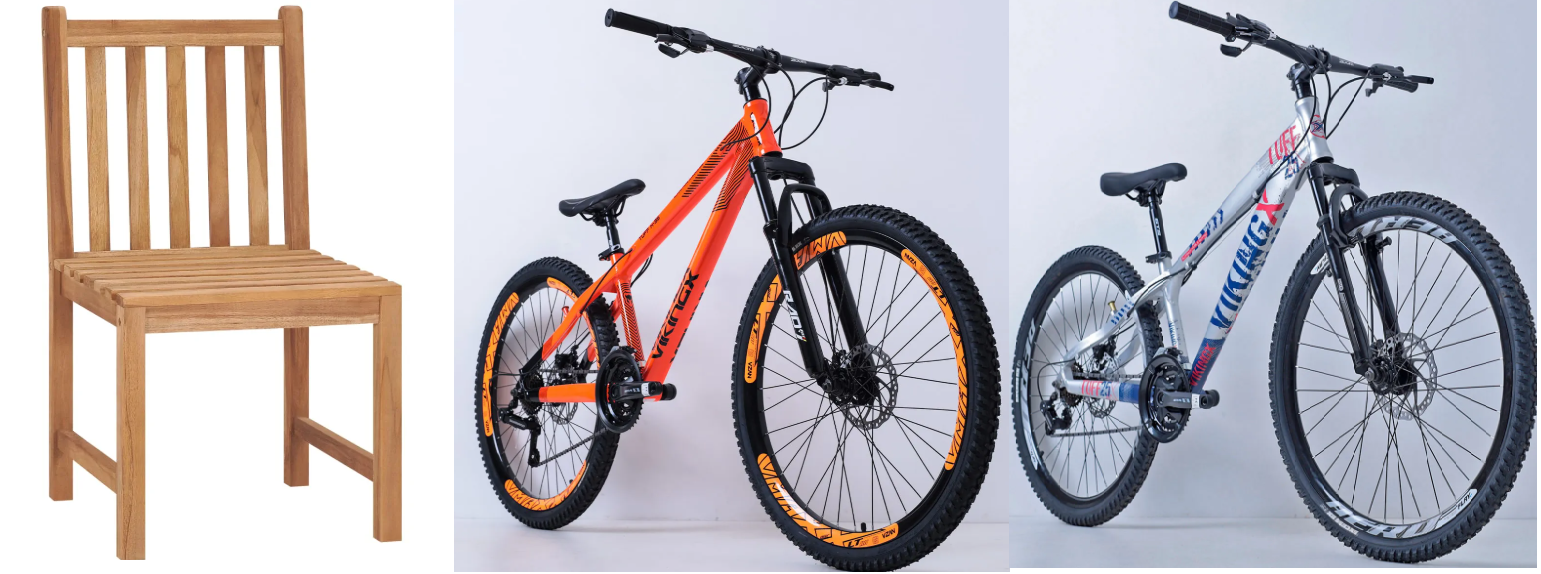

***Resultados Obtidos***

| **Métrica**          | **30 Épocas**                   | **60 Épocas**                  | **Observação**               |
|----------------------|----------------------------------|--------------------------------|-------------------------------|
| `train/box_loss`     | Redução clara, em torno de 0.04 | Redução maior, em torno de 0.02 | Continua melhorando.         |
| `train/obj_loss`     | Em torno de 0.02                | Abaixo de 0.015                | Pequena melhora.             |
| `train/cls_loss`     | Muito baixa, já próxima de zero | Quase zero                     | Saturou cedo.                |
| `val/box_loss`       | Redução visível                 | Ainda menor                    | Melhorou.                    |
| `val/obj_loss`       | Boa queda                       | Melhor ainda                   | Estabilizou.                 |
| `val/cls_loss`       | Já estava muito baixa           | Praticamente zero              | Saturou cedo.                |

-----------------------------------------------------------------------------

| **Métrica**              | **30 Épocas**       | **60 Épocas**       | **Observação**                    |
|--------------------------|---------------------|---------------------|-----------------------------------|
| `metrics/precision`      | Flutua, ~0.9         | Estável em ~1.0     | Melhorou e estabilizou.           |
| `metrics/recall`         | Chega a ~1.0         | Estabiliza em 1.0   | Atinge o máximo.                  |
| `metrics/mAP_0.5`        | ~0.95–1.0            | Estabiliza em 1.0   | Já era excelente e estabilizou.  |
| `metrics/mAP_0.5:0.95`   | ~0.6                 | Atinge ~0.7         | Melhorou com mais treinamento.    |

***Conclusão***

O modelo exibiu excelente desempenho com 30 épocas, apresentando métricas sólidas e perdas bem reduzidas. Com 60 épocas, o sistema mostrou aprendizado ainda mais robusto: as perdas diminuíram significativamente, refletindo ótima otimização, enquanto precisão, recall e mAP se estabilizaram próximos de 1.0, demonstrando alta confiabilidade. O mAP@0.5:0.95, mais exigente, subiu de ~0.6 para ~0.7, indicando detecções mais precisas. A estabilidade das métricas reforça a consistência do modelo, evidenciando seu grande potencial para detecção de imagens.

In [ ]:
from IPython.display import Image
Image(filename='/runs/train/projeto_objetos_30epocas/train_batch0.jpg')